# 09 — Coverage al 68% di $\log\sigma_E$ a N = 150–300 (v0.13)

La checklist v0.11 (notebook 08, report §10–§11) lasciava aperto un punto **(d)**. La coverage al 68%
di $\log\sigma_E$ a N = 150–300 era bassa, 0.60–0.64 contro 0.68, fino a circa 2.4 errori binomiali
sotto il nominale. Al 90% e al 95% invece era nominale. Lo stesso valore usciva anche col prior uguale
al generatore (report §11.2).

Le ipotesi da esaminare, nell'ordine:

1. **forma**: il posterior di $\log\sigma_E$ non è gaussiano, quindi l'intervallo al 68% è più stretto di $\pm 1\,\mathrm{std}$;
2. **asimmetria**: la verità cade fuori sempre dallo stesso lato;
3. **discretizzazione**: il passo della griglia fine 40×40 è troppo largo rispetto all'intervallo al 68%;
4. **posterior troppo stretto**: l'sd dei pull è maggiore di 1;
5. **fluttuazione statistica**.

Le ipotesi 1–4 si guardano sui dati della checklist, senza nuovi run. Per separare la 4 dalla 5 servono
**seed nuovi e indipendenti**: `scripts/caso_C_cov68.py`, con `spawn_key=(N, i, 68)`, N = 150 e
M = 600, N = 300 e M = 300, e il prior di default. Lo stadio 2 è calcolato sia su $\hat\Omega_0$ sia
sulla $\Omega_n$ vera. Il run è stato fatto con 3 processi in circa 11 minuti, e i risultati sono in
`outputs/caso_C_cov68_results.pkl`.

**Etichette.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite · (c) verificato
con Monte Carlo · (d) ipotesi da testare.

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path("..") / "scripts"))
from caso_C_checklist import collect
from riptide_toy import validate

plt.rcParams["figure.dpi"] = 110
with open(Path("..") / "outputs" / "caso_C_checklist_results.pkl", "rb") as f:
    CHECK = pickle.load(f)
with open(Path("..") / "outputs" / "caso_C_cov68_results.pkl", "rb") as f:
    NEW = pickle.load(f)
LEVELS = NEW["LEVELS"]


def from_new(results: list, n: int, which: str) -> dict:
    """Esperimenti del run nuovo a N fissato, stadio 2 su omega_0 ('hat') o su Omega vera ('true')."""
    rows = [r for r in results if r["N"] == n]
    out = {k: np.array([r[k] for r in rows]) for k in ("mu_true", "sigma_true")}
    for k in rows[0][which]:
        out[k] = np.array([r[which][k] for r in rows])
    return out


BLOCKS = {}
for n in (150, 300):
    BLOCKS[(n, "checklist, Ω̂₀")] = collect(CHECK["results"], n)
    BLOCKS[(n, "seed nuovi, Ω̂₀")] = from_new(NEW["results"], n, "hat")
    BLOCKS[(n, "seed nuovi, Ω vera")] = from_new(NEW["results"], n, "true")


def diagnostics(t: dict) -> dict:
    """Coverage, pull, lati dei mancati e larghezza relativa degli intervalli di log sigma_E."""
    lt = np.log(t["sigma_true"])
    ints = t["ls_int"]
    pull = (t["ls_mean"] - lt) / t["ls_std"]
    return {
        "m": lt.size,
        "cov": validate.coverage_curve(lt, ints, LEVELS)[1],
        "cov_mu": validate.coverage_curve(t["mu_true"], t["mu_int"], LEVELS)[1],
        "pull": pull,
        "below": int((lt < ints[:, 0, 0]).sum()), "above": int((lt > ints[:, 0, 1]).sum()),
        "w68": (ints[:, 0, 1] - ints[:, 0, 0]) / (2 * t["ls_std"]),
        "w95": (ints[:, 2, 1] - ints[:, 2, 0]) / (2 * stats.norm.ppf(0.975) * t["ls_std"]),
    }


DIAG = {k: diagnostics(t) for k, t in BLOCKS.items()}
print(f"{'N':>4} {'campione':22s} {'M':>4}  cov log σ 68/90/95      err.binom 68  pull media/sd  kurt  mancati 68 sotto/sopra")
for (n, lab), d in DIAG.items():
    e = np.sqrt(0.68 * 0.32 / d["m"])
    print(f"{n:4d} {lab:22s} {d['m']:4d}  {np.round(d['cov'], 3)!s:22s} ±{e:.3f}"
          f"      {d['pull'].mean():+.2f}/{d['pull'].std():.2f}   {stats.kurtosis(d['pull']):+.2f}   {d['below']}/{d['above']}")

   N campione                  M  cov log σ 68/90/95      err.binom 68  pull media/sd  kurt  mancati 68 sotto/sopra
 150 checklist, Ω̂₀          200  [0.6   0.87  0.945]    ±0.033      -0.02/1.05   -0.64   35/45
 150 seed nuovi, Ω̂₀         600  [0.658 0.895 0.955]    ±0.019      +0.07/0.99   -0.14   103/102
 150 seed nuovi, Ω vera      600  [0.65  0.902 0.957]    ±0.019      -0.06/0.97   -0.32   87/123
 300 checklist, Ω̂₀          100  [0.64 0.87 0.94]       ±0.047      +0.00/1.06   +0.05   20/16
 300 seed nuovi, Ω̂₀         300  [0.723 0.917 0.963]    ±0.027      +0.01/0.92   +0.03   42/41
 300 seed nuovi, Ω vera      300  [0.737 0.917 0.97 ]    ±0.027      -0.07/0.91   +0.22   35/44


## 1–2. Forma e asimmetria (c)

Se il posterior fosse gaussiano, la semiampiezza dell'intervallo a code uguali al 68% sarebbe 1 std, e
quella al 95% 1.96 std. I rapporti misurati sono qui sotto. Una coda pesante darebbe un rapporto al 68%
minore di 1. Una coverage bassa per asimmetria darebbe mancati concentrati da un solo lato.

In [2]:
for (n, lab), d in DIAG.items():
    print(f"N={n:3d} {lab:22s} w68/(2 std) mediana {np.median(d['w68']):.3f} [{np.percentile(d['w68'], 5):.3f}, "
          f"{np.percentile(d['w68'], 95):.3f}]  w95/(3.92 std) mediana {np.median(d['w95']):.3f}")

N=150 checklist, Ω̂₀         w68/(2 std) mediana 1.001 [0.821, 1.007]  w95/(3.92 std) mediana 1.013
N=150 seed nuovi, Ω̂₀        w68/(2 std) mediana 1.000 [0.842, 1.006]  w95/(3.92 std) mediana 1.013
N=150 seed nuovi, Ω vera     w68/(2 std) mediana 1.000 [0.828, 1.007]  w95/(3.92 std) mediana 1.013
N=300 checklist, Ω̂₀         w68/(2 std) mediana 1.004 [0.994, 1.010]  w95/(3.92 std) mediana 1.013
N=300 seed nuovi, Ω̂₀        w68/(2 std) mediana 1.004 [0.988, 1.010]  w95/(3.92 std) mediana 1.013
N=300 seed nuovi, Ω vera     w68/(2 std) mediana 1.004 [0.987, 1.010]  w95/(3.92 std) mediana 1.014


La mediana dei rapporti vale 1.00 al 68% e 1.01 al 95%. A N = 150 il 5° percentile al 68% scende
a circa 0.83: sono gli esperimenti col plateau verso σ_E piccola (report §11.2), rari e presenti in
entrambi i campioni. I mancati sono bilanciati tra i due lati, entro le fluttuazioni di Poisson.
Forma e asimmetria **sono escluse (c)**.

## 3. Discretizzazione della griglia fine (c)

La griglia fine ha 40 punti in $\log\sigma_E$ sulla finestra `WINDOW_DELTA_LOG = 10`, cioè circa
±4.5 std. Il passo vale quindi circa 0.27 std. `validate.credible_interval` interpola linearmente la
CDF ai centri delle celle. Qui si ricalcolano alcuni esperimenti della checklist con una griglia
80×80 e si confrontano gli estremi dell'intervallo al 68%. Richiede circa un minuto.

In [3]:
from riptide_toy import grids, kinematics, posterior_C, priors
from riptide_toy.constants import SEED, SIGMA_EP, SIGMA_THETA
from caso_C_checklist import MU_RANGE, SIGMA_RANGE


def interval_68(n: int, i: int, n_fine: int) -> tuple:
    """Intervallo al 68% di log sigma_E e std posteriore, esperimento (n, i) della checklist, griglia n_fine^2."""
    rng = np.random.default_rng(np.random.SeedSequence(SEED, spawn_key=(n, i)))
    mu = rng.uniform(*MU_RANGE)
    sg = np.exp(rng.uniform(*np.log(SIGMA_RANGE)))
    om = kinematics.direction_from_theta_phi(np.arccos(rng.uniform(-1.0, 1.0, 1)), rng.uniform(0.0, 2 * np.pi, 1))
    Ep, tr = kinematics.sample_recoil_events(rng, rng.normal(mu, sg, n), om[0])
    D_B = (rng.normal(Ep, SIGMA_EP), kinematics.smear_direction(rng, tr, SIGMA_THETA))
    tg, pg = grids.sphere_grid()
    mg, sgg = grids.hyperparameter_grid()
    D = (*D_B, posterior_C.refine_shared_direction(D_B, tg, pg, priors.direction_prior(tg, pg))[0])
    lp, _, sf = posterior_C.refine_hyperparameters(D, mg, sgg, priors.hyperparameter_prior,
                                                   n_mu=n_fine, n_sigma=n_fine)
    _, std = validate.posterior_mean_std(lp[None], np.log(sf))
    return validate.credible_interval(lp[None], np.log(sf), np.array([0.68]))[0, 0], std[0]


for n, i in [(150, 0), (150, 1), (150, 2), (300, 0), (300, 1)]:
    (i40, s40), (i80, _) = interval_68(n, i, 40), interval_68(n, i, 80)
    print(f"N={n} i={i}: std {s40:.3f}, 68% 40×40 {np.round(i40, 3)}, 80×80 {np.round(i80, 3)},"
          f" max|Δ|/std {np.abs(i40 - i80).max() / s40:.3f}")

N=150 i=0: std 0.152, 68% 40×40 [-1.377 -1.074], 80×80 [-1.377 -1.076], max|Δ|/std 0.011
N=150 i=1: std 0.232, 68% 40×40 [-1.757 -1.311], 80×80 [-1.748 -1.313], max|Δ|/std 0.036
N=150 i=2: std 0.172, 68% 40×40 [-1.564 -1.222], 80×80 [-1.562 -1.224], max|Δ|/std 0.012
N=300 i=0: std 0.075, 68% 40×40 [-0.843 -0.693], 80×80 [-0.843 -0.693], max|Δ|/std 0.008
N=300 i=1: std 0.081, 68% 40×40 [-0.798 -0.634], 80×80 [-0.797 -0.635], max|Δ|/std 0.012


Raddoppiando la griglia gli estremi si spostano di circa l'1% della std. Nella diagnostica su 14
esperimenti il massimo è stato 0.036 std. Un effetto così sposta la coverage di pochi millesimi, quindi
la discretizzazione **è esclusa (c)**.

## 4–5. Posterior troppo stretto o fluttuazione? Seed nuovi (c)

Sui seed della checklist l'sd dei pull vale 1.05–1.06. Con un pull gaussiano di sd $s$ la coverage
attesa al livello $L$ è $2\Phi(z_L/s)-1$, che per $s = 1.06$ al 68% dà circa 0.65. L'ipotesi 4
spiegherebbe quindi una parte del deficit. Il run su seed nuovi la mette alla prova.

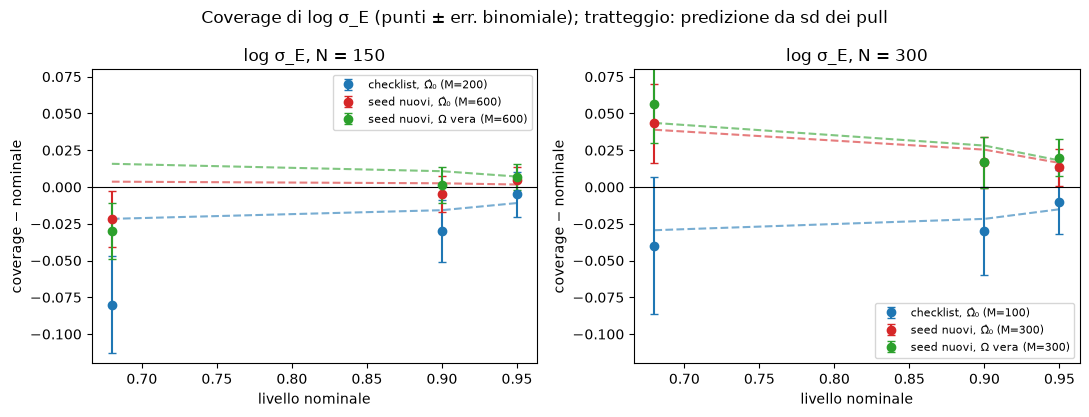

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, n in zip(axes, (150, 300)):
    for lab, c in (("checklist, Ω̂₀", "C0"), ("seed nuovi, Ω̂₀", "C3"), ("seed nuovi, Ω vera", "C2")):
        d = DIAG[(n, lab)]
        err = np.sqrt(LEVELS * (1 - LEVELS) / d["m"])
        ax.errorbar(LEVELS, d["cov"] - LEVELS, yerr=err, fmt="o", color=c, capsize=3,
                    label=f"{lab} (M={d['m']})")
        pred = 2 * stats.norm.cdf(stats.norm.ppf(0.5 + LEVELS / 2) / d["pull"].std()) - 1
        ax.plot(LEVELS, pred - LEVELS, "--", color=c, alpha=0.6)
    ax.axhline(0, color="k", lw=0.8)
    ax.set(title=f"log σ_E, N = {n}", xlabel="livello nominale", ylabel="coverage − nominale", ylim=(-0.12, 0.08))
    ax.legend(fontsize=8)
fig.suptitle("Coverage di log σ_E (punti ± err. binomiale); tratteggio: predizione da sd dei pull")
fig.tight_layout()

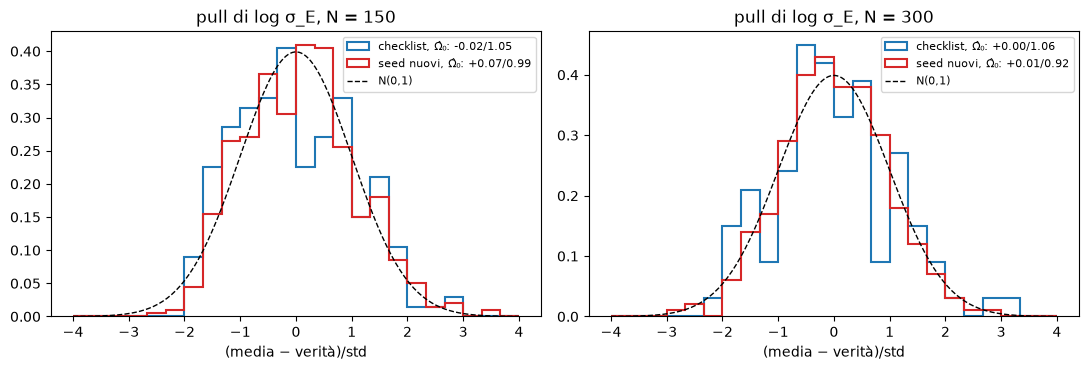

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.linspace(-4, 4, 200)
for ax, n in zip(axes, (150, 300)):
    for lab, c in (("checklist, Ω̂₀", "C0"), ("seed nuovi, Ω̂₀", "C3")):
        p = DIAG[(n, lab)]["pull"]
        ax.hist(p, bins=np.linspace(-4, 4, 25), density=True, histtype="step", color=c, lw=1.5,
                label=f"{lab}: {p.mean():+.2f}/{p.std():.2f}")
    ax.plot(x, stats.norm.pdf(x), "k--", lw=1, label="N(0,1)")
    ax.set(title=f"pull di log σ_E, N = {n}", xlabel="(media − verità)/std")
    ax.legend(fontsize=8)
fig.tight_layout()

Sui seed nuovi:

- la coverage al 68% vale 0.658 ± 0.019 a N = 150, cioè −1.2 errori binomiali, e 0.723 ± 0.027 a
  N = 300, cioè +1.6;
- l'sd dei pull vale 0.99 a N = 150 e 0.92 a N = 300;
- lo scarto va in direzioni opposte ai due N, e l'eccesso di sd visto sui seed della checklist
  **non si ripresenta**.

L'ipotesi 4 (posterior troppo stretto) **è falsificata (c)**. Lo stadio 1 non conta: le coverage con
$\hat\Omega_0$ e con la $\Omega_n$ vera sono compatibili.

## Significatività combinata e confronti multipli

In [6]:
def z_score(cov: float, m: int, level: float = 0.68) -> float:
    return (cov - level) / np.sqrt(level * (1 - level) / m)


old = [DIAG[(n, "checklist, Ω̂₀")] for n in (150, 300)]
new = [DIAG[(n, "seed nuovi, Ω̂₀")] for n in (150, 300)]
for tag, blocks in (("checklist", old), ("seed nuovi", new), ("tutti", old + new)):
    m = sum(d["m"] for d in blocks)
    c = sum(d["cov"][0] * d["m"] for d in blocks) / m
    print(f"{tag:10s}: coverage 68% combinata N=150+300 = {c:.3f} (M = {m}), z = {z_score(c, m):+.2f}")
n_checks = 4 * 3 * 2  # N x livelli x parametri (mu_E, log sigma_E) nella checklist v0.11
p_one = 2 * stats.norm.sf(2.4)
print(f"\nprobabilità di almeno un |z| ≥ 2.4 su {n_checks} coverage (indip.): {1 - (1 - p_one) ** n_checks:.2f}")

checklist : coverage 68% combinata N=150+300 = 0.613 (M = 300), z = -2.48
seed nuovi: coverage 68% combinata N=150+300 = 0.680 (M = 900), z = +0.00
tutti     : coverage 68% combinata N=150+300 = 0.663 (M = 1200), z = -1.24

probabilità di almeno un |z| ≥ 2.4 su 24 coverage (indip.): 0.33


Sui 900 esperimenti nuovi la coverage al 68% combinata è esattamente nominale (0.680). Aggiungendo i
300 della checklist resta a −1.2 errori binomiali.
La checklist v0.11 contiene circa 24 coverage: 4 N, 3 livelli e 2 parametri scalari. Con tante
prove, un solo scarto di 2.4σ capita in circa un terzo dei casi.

## Esito

- La coverage al 68% di $\log\sigma_E$ a N = 150–300 **è nominale (c)**. Il valore basso dei seed
  della checklist era una **fluttuazione statistica**.
- Forma del posterior, asimmetria dei mancati, discretizzazione della griglia fine e stadio 1 sono
  esclusi uno per uno.
- La calibrazione di $\log\sigma_E$ è confermata con M = 600 a N = 150: pull 0.07 ± 0.04 di media e
  sd 0.99.
- Resta un punto al limite, **(d)**: la coverage al 90% di $\mu_E$ a N = 300. Valeva 0.84 ± 0.037 sui
  seed della checklist e vale 0.877 ± 0.017 su quelli nuovi, cioè −1.4 errori. La sd dei pull di
  $\mu_E$ è 1.03, quindi non c'è un segnale netto. Va tenuto d'occhio, ma non richiede un'azione.

In [7]:
for n in (150, 300):
    for lab in ("checklist, Ω̂₀", "seed nuovi, Ω̂₀"):
        d, t = DIAG[(n, lab)], BLOCKS[(n, lab)]
        pm = (t["mu_mean"] - t["mu_true"]) / t["mu_std"]
        print(f"N={n} {lab:16s} M={d['m']:3d} μ_E coverage {np.round(d['cov_mu'], 3)}  pull {pm.mean():+.2f}/{pm.std():.2f}")

N=150 checklist, Ω̂₀   M=200 μ_E coverage [0.695 0.915 0.955]  pull +0.03/0.98
N=150 seed nuovi, Ω̂₀  M=600 μ_E coverage [0.703 0.915 0.955]  pull +0.06/1.00
N=300 checklist, Ω̂₀   M=100 μ_E coverage [0.66 0.84 0.91]  pull -0.02/1.14
N=300 seed nuovi, Ω̂₀  M=300 μ_E coverage [0.69  0.877 0.933]  pull -0.09/1.03
